# Aprendizado por Reforço

---

**Professor:** Prof. Gabriel Lima  
**Aula:** 04  
**Exercício:** 4C  

---

### Objetivo :  
Implementar os algoritmos descritos abaixo para o problema Roulette do Gymnasium. 

- First Visit Monte Carlo Policy Evaluation
- TD(0) Policy Evaluation

## Bibliotecas Utilizadas

Para a implementação dos algoritmos utilizaremos as seguintes bibliotecas: 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium
from gymnasium import spaces
from gymnasium.utils import seeding

## Definição do Ambiente

Considere o seguinte ambiente a ser implementado:

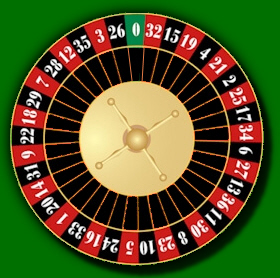


- 𝒮 = {0}  
  - Há apenas um estado observável. A dinâmica do ambiente não depende do estado atual.  

- 𝒜 = {0, 1, ..., 36, 37}  
  - Ações de 0 a 36 correspondem a apostas em números específicos da roleta.  
  - A ação 37 representa "sair da roleta", encerrando o episódio.  

- ℛ(s, a) é definido da seguinte forma:  
  - ℛ(0, 37) = 0  
  - ℛ(0, a) =  
    - **35** se `a = 0` e o número sorteado também é 0  
    - **1** se `a ≠ 0`, o número sorteado também é diferente de 0, e ambos têm a mesma paridade (par ou ímpar)  
    - **−1** caso contrário  

- 𝒫 é **estocástico**, com distribuição uniforme sobre os 37 números possíveis (0 a 36):  
  - 𝒫₀₀ᵃ = 1/37 para cada possível número da roleta  
  - A transição não altera o estado (permanece em 0), mas afeta o retorno  

- O agente **sempre observa o mesmo estado (0)** e deve **decidir entre continuar apostando ou sair**.  

- 𝛾 = definido externamente (pode ser qualquer valor entre 0 e 1, dependendo do setup do agente)  

- O episódio termina **somente** quando o agente escolhe a ação 37.  

Exemplo extraído de:

https://github.com/openai/gym/blob/v0.10.5/gym/envs/toy_text/roulette.py

In [2]:
class RouletteEnv(gymnasium.Env):
    """Simple roulette environment

    The roulette wheel has 37 spots. If the bet is 0 and a 0 comes up,
    you win a reward of 35. If the parity of your bet matches the parity
    of the spin, you win 1. Otherwise you receive a reward of -1.

    The long run reward for playing 0 should be -1/37 for any state

    The last action (38) stops the rollout for a return of 0 (walking away)
    """
    def __init__(self, spots=37):
        self.n = spots + 1
        self.action_space = spaces.Discrete(self.n)
        self.observation_space = spaces.Discrete(1)
        self.seed()

    def seed(self, seed=None):
        self.np_random, seed = seeding.np_random(seed)
        return [seed]

    def step(self, action):
        assert self.action_space.contains(action)
        if action == self.n - 1:
            # observation, reward, done, info
            return 0, 0, True, {}

        # N.B. np.random.randint draws from [A, B) while random.randint draws from [A,B]
        val = self.np_random.integers(0, self.n - 1)
        if val == action == 0:
            reward = self.n - 2.0
        elif val != 0 and action != 0 and val % 2 == action % 2:
            reward = 1.0
        else:
            reward = -1.0
        return 0, reward, False, {}

    def reset(self):
        return 0

### Instanciando o Ambiente

In [3]:
env = RouletteEnv()

### Verificando o Estado e as Ações

In [4]:
print(env.observation_space)

Discrete(1)


In [5]:
print(env.action_space)

Discrete(38)


## Definindo Variaveis Importantes

In [6]:
action_space = list(np.arange(env.action_space.n))
gamma = 0.95
Max_T_per_episode = 1000

In [7]:
print(action_space)

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37)]


## Criando um Episódio Teste

In [8]:
state = env.reset()
print(f'Estado Inicial: {state}')

action = env.action_space.sample()
print(f'Ação: {action}')

next_state, reward, done, _ = env.step(action)
print(f'Proximo Estado: {next_state}')

print(f'Recompensa:{reward}')
print(f'Done:{done}')

Estado Inicial: 0
Ação: 33
Proximo Estado: 0
Recompensa:-1.0
Done:False


## Definindo a Política

Admitindo uma política aleatória.

In [9]:
random_policy = (1/env.action_space.n)*np.ones(env.action_space.n)

In [10]:
print(random_policy)

[0.02631579 0.02631579 0.02631579 0.02631579 0.02631579 0.02631579
 0.02631579 0.02631579 0.02631579 0.02631579 0.02631579 0.02631579
 0.02631579 0.02631579 0.02631579 0.02631579 0.02631579 0.02631579
 0.02631579 0.02631579 0.02631579 0.02631579 0.02631579 0.02631579
 0.02631579 0.02631579 0.02631579 0.02631579 0.02631579 0.02631579
 0.02631579 0.02631579 0.02631579 0.02631579 0.02631579 0.02631579
 0.02631579 0.02631579]


## Instanciando o Agente

In [11]:
class Agent:
    def __init__(self, policy):
        self.policy = policy

    def get_action(self,action_space):
        idx    = np.random.choice(action_space,p=self.policy)
        action = action_space[idx]
        return action

In [12]:
A = Agent(random_policy)

## Definição da Classe de Transição

In [13]:
class Transition():
    def __init__(self,state,action,reward,next_state,done):
        self.state = state
        self.action = action
        self.reward = reward
        self.next_state = next_state
        self.done = done

## Função Episódio

In [14]:
def episodes(env,agent):
  ep = []
  done  = False
  state = env.reset()
  count =0

  while True:
    count += 1
    action = A.get_action(action_space)
    next_state, reward, done,_ = env.step(action)

    transition = Transition(state,action,reward,next_state,done)
    ep.append(transition)
    state = next_state

    if done or count == Max_T_per_episode:
      break

  return ep

In [15]:
ep = episodes(env, A)

### Visualização

In [16]:
def plot_episode(episode):

    rewards = [t.reward for t in episode]
    plt.style.use('fivethirtyeight')
    fig = plt.figure()
    ax = fig.gca()
    ax.plot(rewards, lw=2)
    fig.suptitle('Episode Rewards')
    ax.set_xlabel('Timestep t')
    ax.set_ylabel('Reward r')
    print('Average Reward = ' + str(np.mean(rewards)))

Average Reward = -0.06060606060606061


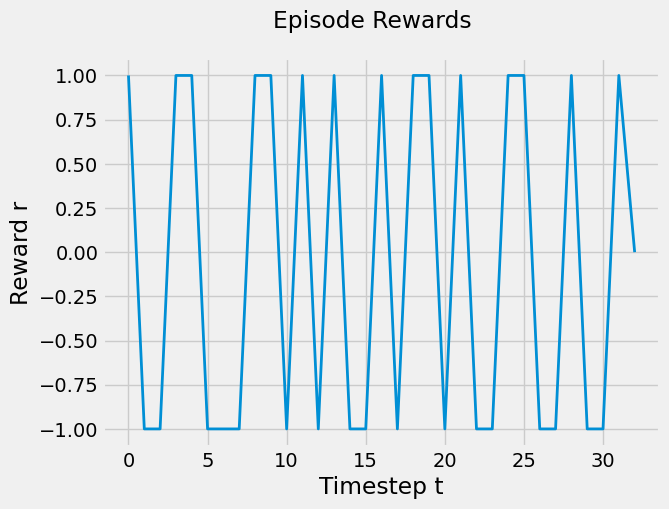

In [17]:
plot_episode(ep)
plt.show()

## First Visit Monte Carlo Policy Evaluation

### Algoritmo

**Entrada:**
- Política 𝜋  
- Número de episódios 𝑁  
- Agente

**Inicialização:**
- V(s) ← 0, ∀ s ∈ 𝒮  
- N(s) ← 0 (contador de visitas), ∀ s ∈ 𝒮

**Repetir para cada episódio (até N episódios):**  
1. Gerar um episódio completo seguindo a política 𝜋:  
   → sequência: (s₀, a₀, r₁, s₁, a₁, r₂, ..., s_T)  
2. G ← 0  
3. visited ← []  
4. Para t = T − 1 até 0 (de trás pra frente):  
   a. G ← γ × G + rₜ₊₁  
   b. Se sₜ **ainda não apareceu** em `visited`:  
      i. adicionar sₜ à lista `visited`  
      ii. N(sₜ) ← N(sₜ) + 1  
      iii. V(sₜ) ← V(sₜ) + (1 / N(sₜ)) × [G − V(sₜ)]

**Saída:**  
- Função de valor V(s) para todos os estados sob a política 𝜋

In [18]:
def monte_carlo_policy_evaluation(env,agent,N_eps=1000):
    m = env.action_space.n
    # Initialize Sum of Returns S and State Visit Count N
    S = np.zeros(m)
    N = np.zeros(m)
    # Loop over episodes
    for i in range(N_eps):

        episode = episodes(env,agent)
        G = 0
        T = len(episode)
        # Loop over timesteps on episode
        for t in range(T-1,-1,-1):
            transition = episode[t]
            G = gamma*G + transition.reward
            idx = transition.action
            N[idx] += 1
            S[idx] += G

    # Value Function Estimate Q ~ S/N
    Q = S/N
    return Q

In [19]:
Q = monte_carlo_policy_evaluation(env,A,N_eps=10000)
print(Q)

[-0.35697264 -0.36059917 -0.39559577 -0.37407486 -0.38855375 -0.39518259
 -0.36197859 -0.34139809 -0.39568048 -0.43138395 -0.33159473 -0.39052351
 -0.39089473 -0.3539514  -0.36036093 -0.34623478 -0.43270453 -0.34775891
 -0.4700463  -0.38433557 -0.38385209 -0.32782238 -0.32459328 -0.36705893
 -0.38505349 -0.36712483 -0.35497153 -0.30175761 -0.43797797 -0.44296655
 -0.38787776 -0.39111059 -0.34094376 -0.34340584 -0.41505693 -0.33761663
 -0.38783648  0.        ]


### Visualização

In [20]:
def plot_Q_values(Q):
    fig = plt.figure()
    ax = fig.gca()
    ax.plot(Q,lw=2)
    fig.suptitle(r'State-Action Value Function $Q_{\pi}(s,a)$')
    ax.set_xlabel(r'Action a')
    ax.set_ylabel(r'$Q_{\pi}(s,a)$')

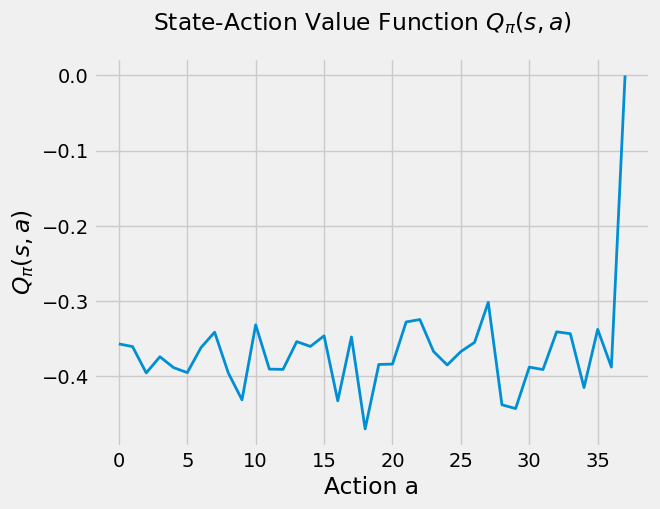

In [21]:
plot_Q_values(Q)